In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 10 MW / 20 MWh BESS ARBITRAGE SIMULATION & FINANCIAL MODEL
Total CAPEX:                       €4,400,000.00
Estimated Annual Arbitrage Revenue: €585,840.17
Annual OPEX (2% of CAPEX):         €88,000.00
Net Annual Cash Flow:              €497,840.17
Project Lifetime:                  15 Years
Net Present Value (NPV @ 7%):      €134,285.49
Simple Payback Period:             8.84 Years


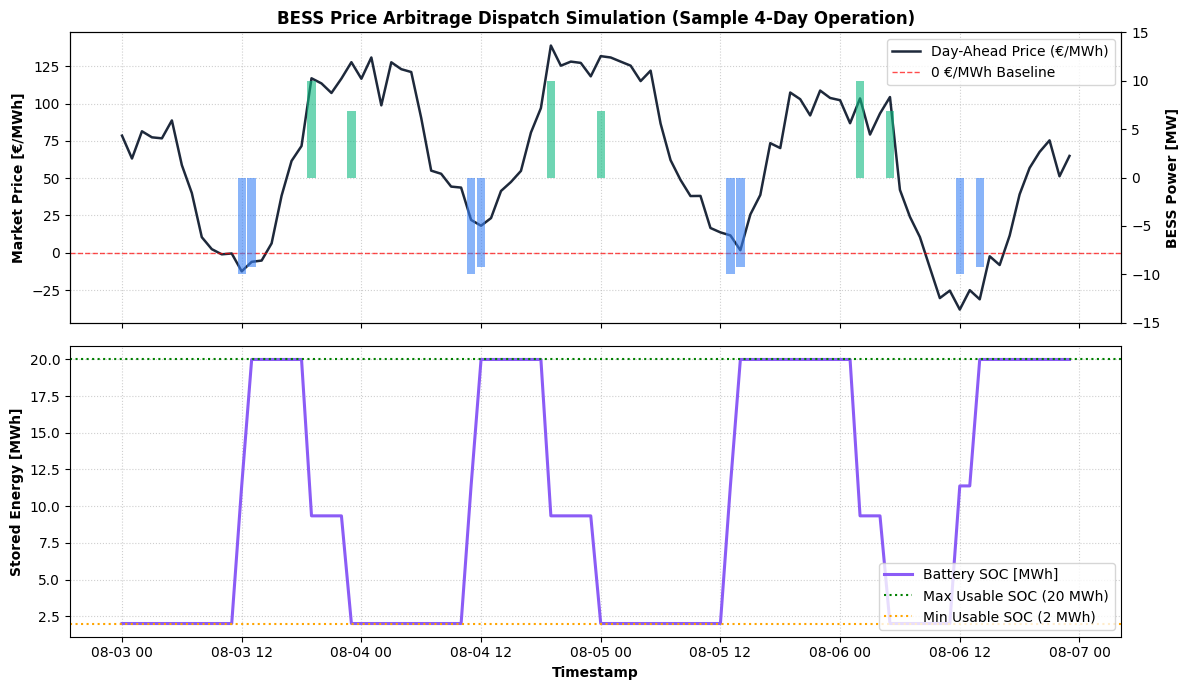

Simulation dataset saved as 'bess_arbitrage_dispatch_simulation_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. MARKET PRICE PROFILE SIMULATION
# ==========================================
dates = pd.date_range(
    start="2026-08-01 00:00:00", periods=24 * 30, freq="h"
)  # 30-Day hourly horizon
np.random.seed(42)
hours = dates.hour.to_numpy()
dayofweek = dates.dayofweek.to_numpy()

# Physics-based German Day-Ahead Merit-Order Price curve
solar_shape = np.maximum(0, np.sin((hours - 5) * np.pi / 14))
wind_shape = 0.5 + 0.4 * np.sin(np.linspace(0, 12 * np.pi, len(dates)))
load_shape = 45000 + 15000 * np.clip(np.sin((hours - 6) * np.pi / 12), 0, None)
weekend_factor = np.where(dayofweek >= 5, 0.8, 1.0)
grid_load = load_shape * weekend_factor

residual_load = grid_load - (solar_shape * 45000 + wind_shape * 25000)
base_prices = (
    35.0 + (residual_load - 15000) * 0.0035 + np.random.normal(0, 8, len(dates))
)
prices = np.round(base_prices, 2)

df_bess = pd.DataFrame(
    {"timestamp": dates, "hour": hours, "price_eur_mwh": prices}
)

# ==========================================
# 2. BESS TECHNICAL PARAMETERS (10 MW / 20 MWh)
# ==========================================
P_MAX = 10.0  # Rated Power (MW)
CAPACITY_MWH = 20.0  # Usable Energy Capacity (MWh)
ROUND_TRIP_EFFICIENCY = 0.88  # 88% RTE
CHARGE_EFF = np.sqrt(ROUND_TRIP_EFFICIENCY)
DISCHARGE_EFF = np.sqrt(ROUND_TRIP_EFFICIENCY)
DOD_MAX = 0.90  # 90% Usable Depth of Discharge
SOC_MIN = CAPACITY_MWH * (1 - DOD_MAX)  # 2.0 MWh
SOC_MAX = CAPACITY_MWH  # 20.0 MWh

# ==========================================
# 3. DYNAMIC ARBITRAGE DISPATCH OPTIMIZATION
# ==========================================
soc = 10.0  # Initial State of Charge (50%)
bess_power = []  # MW (+Discharge, -Charge)
soc_history = []
revenue_history = []

for day, day_df in df_bess.groupby(df_bess["timestamp"].dt.date):
  day_prices = day_df["price_eur_mwh"].values

  # Select lowest 2 hours for charging, highest 2 hours for discharging
  charge_hours_idx = np.argsort(day_prices)[:2]
  discharge_hours_idx = np.argsort(day_prices)[-2:]

  for h in range(len(day_prices)):
    p = day_prices[h]
    power = 0.0

    if h in charge_hours_idx and soc < SOC_MAX:
      max_energy_can_add = (SOC_MAX - soc) / CHARGE_EFF
      power_to_charge = min(P_MAX, max_energy_can_add)
      power = -power_to_charge
      soc += power_to_charge * CHARGE_EFF
    elif h in discharge_hours_idx and soc > SOC_MIN:
      max_energy_can_extract = (soc - SOC_MIN) * DISCHARGE_EFF
      power_to_discharge = min(P_MAX, max_energy_can_extract)
      power = power_to_discharge
      soc -= power_to_discharge / DISCHARGE_EFF

    hourly_rev = power * p
    bess_power.append(power)
    soc_history.append(soc)
    revenue_history.append(hourly_rev)

df_bess["bess_power_mw"] = bess_power
df_bess["soc_mwh"] = soc_history
df_bess["revenue_eur"] = revenue_history

# ==========================================
# 4. FINANCIAL MODELING & DCF PROJECTIONS
# ==========================================
monthly_revenue = df_bess["revenue_eur"].sum()
annual_revenue_est = monthly_revenue * 12

CAPEX_PER_KWH = 220  # EUR/kWh installed
TOTAL_CAPEX = CAPACITY_MWH * 1000 * CAPEX_PER_KWH  # EUR 4,400,000
ANNUAL_OPEX = TOTAL_CAPEX * 0.02  # 2% of CAPEX (EUR 88,000/yr)
DISCOUNT_RATE = 0.07  # 7% WACC
PROJECT_LIFETIME = 15  # Years

net_annual_cashflow = annual_revenue_est - ANNUAL_OPEX
cash_flows = [-TOTAL_CAPEX] + [net_annual_cashflow] * PROJECT_LIFETIME
npv = sum(cf / ((1 + DISCOUNT_RATE) ** t) for t, cf in enumerate(cash_flows))
simple_payback = TOTAL_CAPEX / net_annual_cashflow

print("=" * 65)
print(" 10 MW / 20 MWh BESS ARBITRAGE SIMULATION & FINANCIAL MODEL")
print("=" * 65)
print(f"Total CAPEX:                       €{TOTAL_CAPEX:,.2f}")
print(f"Estimated Annual Arbitrage Revenue: €{annual_revenue_est:,.2f}")
print(f"Annual OPEX (2% of CAPEX):         €{ANNUAL_OPEX:,.2f}")
print(f"Net Annual Cash Flow:              €{net_annual_cashflow:,.2f}")
print(f"Project Lifetime:                  {PROJECT_LIFETIME} Years")
print(f"Net Present Value (NPV @ 7%):      €{npv:,.2f}")
print(f"Simple Payback Period:             {simple_payback:.2f} Years")
print("=" * 65)

# ==========================================
# 5. VISUALIZATION & ASSET EXPORT
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
sample_df = df_bess.iloc[24 * 2 : 24 * 6]

# Subplot 1: Price and Dispatch
ax1.plot(
    sample_df["timestamp"],
    sample_df["price_eur_mwh"],
    color="#1E293B",
    lw=1.8,
    label="Day-Ahead Price (€/MWh)",
)
ax1.axhline(
    0, color="red", linestyle="--", lw=1, alpha=0.7, label="0 €/MWh Baseline"
)
ax1.set_ylabel("Market Price [€/MWh]", fontweight="bold")
ax1.set_title(
    "BESS Price Arbitrage Dispatch Simulation (Sample 4-Day Operation)",
    fontweight="bold",
    fontsize=12,
)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

ax1_twin = ax1.twinx()
ax1_twin.bar(
    sample_df["timestamp"],
    sample_df["bess_power_mw"],
    width=0.035,
    color=np.where(sample_df["bess_power_mw"] > 0, "#10B981", "#3B82F6"),
    alpha=0.6,
    label="BESS Power (+Discharge/-Charge)",
)
ax1_twin.set_ylabel("BESS Power [MW]", fontweight="bold")
ax1_twin.set_ylim(-15, 15)

# Subplot 2: State of Charge
ax2.plot(
    sample_df["timestamp"],
    sample_df["soc_mwh"],
    color="#8B5CF6",
    lw=2.2,
    label="Battery SOC [MWh]",
)
ax2.axhline(
    SOC_MAX, color="green", linestyle=":", label="Max Usable SOC (20 MWh)"
)
ax2.axhline(
    SOC_MIN, color="orange", linestyle=":", label="Min Usable SOC (2 MWh)"
)
ax2.set_ylabel("Stored Energy [MWh]", fontweight="bold")
ax2.set_xlabel("Timestamp", fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig("bess_arbitrage_dispatch_simulation.png", dpi=300)
plt.show()

# Export simulation dataset
df_bess.to_csv("bess_arbitrage_dispatch_simulation_2026.csv", index=False)
print("Simulation dataset saved as 'bess_arbitrage_dispatch_simulation_2026.csv'")